# Stationary and nonstationary computations

**What this shows:** the ways SWAN can compute over time, how to set each one up with
`MODE` and `LOCKUP`, and how their results differ.

**Prerequisites:** [Tutorial 6: A nonstationary hindcast](../tutorial/06_nonstationary_hindcast.ipynb).

**You will learn:**

- the difference between SWAN's mode and its computations
- how to set up a single stationary computation, a series of them, and a
  nonstationary computation
- what rompy-swan checks, and how the run period sets the computation times
- when a series of stationary computations is a good approximation

**Data used:** `etopo15s_perth.nc`, `era5-20230101.nc` and
`ww3-spectra-20230101-short.nc`.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pydantic import ValidationError
from rompy.backends import DockerConfig
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_swan.boundary import Boundnest1
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_NONSTAT, COMPUTE_STAT
from rompy_swan.components.output import POINTS, TABLE
from rompy_swan.components.physics import FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface, LockupInterface
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL
from rompy_swan.subcomponents.time import NONSTATIONARY

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "stationary_and_nonstationary"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Mode and computations

SWAN separates two things:

- **`MODE`** says whether the model has a notion of time. In `STATIONARY` mode
  (SWAN's default) there is none: inputs, boundaries and output have no times, and
  SWAN computes one wave field. In `NONSTATIONARY` mode, inputs and output have times.
- **`COMPUTE`** runs a computation. In nonstationary mode, a computation can be
  stationary (the equilibrium wave field for the conditions at one time) or
  nonstationary (the waves evolving from one time step to the next).

rompy-swan's `LOCKUP` takes the computation, and the run period sets its times. Here
is what each option writes for a six-hour period with a two-hour interval:

In [2]:
period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T06:00", interval="2h")
options = {
    "one stationary computation": COMPUTE_STAT(),
    "a series of stationary computations": COMPUTE_STAT(times=NONSTATIONARY()),
    "a nonstationary computation": COMPUTE_NONSTAT(),
    "stationary start, then nonstationary": COMPUTE_NONSTAT(initstat=True),
}
for name, compute in options.items():
    lockup = LockupInterface(group=LOCKUP(compute=compute), period=period).group
    print(f"{name}:\n{lockup.render()}")

one stationary computation:
COMPUTE STATIONARY time=20230101.000000
STOP
a series of stationary computations:
COMPUTE STATIONARY time=20230101.000000
COMPUTE STATIONARY time=20230101.020000
COMPUTE STATIONARY time=20230101.040000
COMPUTE STATIONARY time=20230101.060000
STOP
a nonstationary computation:
COMPUTE NONSTATIONARY tbegc=20230101.000000 deltc=7200.0 SEC tendc=20230101.060000
STOP
stationary start, then nonstationary:
COMPUTE STATIONARY time=20230101.000000
COMPUTE NONSTATIONARY tbegc=20230101.000000 deltc=7200.0 SEC tendc=20230101.060000
STOP


In stationary mode, rompy-swan writes a plain `COMPUTE` without a time, which is all
SWAN accepts there.

## 2. What fits together

| `MODE` | Computation | Inputs and boundaries |
|---|---|---|
| stationary | one `COMPUTE_STAT` | bottom, constant wind, `BOUNDSPEC` with constant parameters |
| nonstationary | `COMPUTE_STAT`, a series of them, or `COMPUTE_NONSTAT` | anything, including time-varying data |

rompy-swan checks the combinations when the configuration is created:

In [3]:
cgrid = REGULAR(
    grid=dict(xp=0, yp=0, alp=0, xlen=1000, ylen=1000, mx=10, my=10),
    spectrum=dict(mdc=36, flow=0.04, fhigh=1.0),
)
try:
    SwanConfig(cgrid=cgrid, lockup=LOCKUP(compute=COMPUTE_NONSTAT()))
except ValidationError as err:
    print(err)

1 validation error for SwanConfig
  Value error, In stationary mode (MODE STATIONARY, SWAN's default) SWAN accepts only a single stationary computation. Set startup.mode=MODE(kind='nonstationary'); a stationary computation at a given time is then COMPUTE_STAT. [type=value_error, input_value={'cgrid': REGULAR(model_t...%M%S', initstat=False))}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


## 3. A series of stationary computations or a nonstationary run?

For small domains, where waves cross the grid in less than the time step, a series of
stationary computations is a good approximation, and allows long steps. For larger
domains, the waves take time to travel and grow, which only a nonstationary
computation represents.

We compare the two over six hours at an offshore point and off Cottesloe, with the
model of Tutorial 6: stationary computations every two hours, and a nonstationary
computation with 10-minute steps.

In [4]:
grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)


def swan_config(compute) -> SwanConfig:
    """The hindcast model of Tutorial 6 with the given computation."""
    return SwanConfig(
        startup=STARTUP(
            set=SET(direction_convention="nautical"),
            mode=MODE(kind="nonstationary"),
            coordinates=COORDINATES(kind=SPHERICAL()),
        ),
        cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
        inpgrid=DataInterface(
            bottom=SwanDataGrid(
                var="bottom",
                source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
                z1="z",
                fac=-1.0,
                coords={"x": "longitude", "y": "latitude"},
                buffer=0.1,
            ),
            input=[
                SwanDataGrid(
                    var="wind",
                    source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
                    z1="u10",
                    z2="v10",
                    coords={"x": "longitude", "y": "latitude"},
                    filter=Filter(sort={"coords": ["latitude"]}),
                    buffer=0.25,
                )
            ],
        ),
        boundary=BoundaryInterface(
            kind=Boundnest1(
                id="ww3",
                source=SourceWavespectra(
                    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
                ),
                sel_method="idw",
                sel_method_kwargs={"tolerance": 1.5},
                spacing=0.1,
            )
        ),
        physics=PHYSICS(gen=GEN3(), friction=FRICTION_JONSWAP(cfjon=0.038), triad=TRIAD()),
        output=OUTPUT(
            points=POINTS(sname="sites", xp=[114.8, 115.71], yp=[-32.1, -31.98]),
            table=TABLE(sname="sites", format="noheader", fname="sites.txt", output=["time", "hsign"]),
        ),
        lockup=LOCKUP(compute=compute),
    )


runs = {
    "stationary series": (
        swan_config(COMPUTE_STAT(times=NONSTATIONARY())),
        TimeRange(start="2023-01-01T06:00", end="2023-01-01T12:00", interval="2h"),
    ),
    "nonstationary": (
        swan_config(COMPUTE_NONSTAT(initstat=True)),
        TimeRange(start="2023-01-01T06:00", end="2023-01-01T12:00", interval="10m"),
    ),
}

In [5]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
tables = {}
for name, (config, period) in runs.items():
    modelrun = ModelRun(run_id=name.replace(" ", "_"), period=period, output_dir=OUT_DIR, config=config)
    workspace = Path(modelrun())
    if docker_available() and modelrun.run(backend, workspace_dir=workspace):
        table = pd.read_csv(
            workspace / "sites.txt", sep=r"\s+", names=["time", "hs"], dtype={"time": str}
        )
        table["time"] = pd.to_datetime(table["time"], format="%Y%m%d.%H%M%S")
        table["site"] = ["offshore", "Cottesloe"] * (len(table) // 2)
        tables[name] = table
print(f"Runs completed: {list(tables)}")

Runs completed: ['stationary series', 'nonstationary']


The morning sea breeze strengthens over these six hours. The stationary computations
put the waves in equilibrium with the wind at once, while in the nonstationary run
they take time to grow, so its wave height lags behind. With stronger or faster
changes, or larger domains, the difference grows.

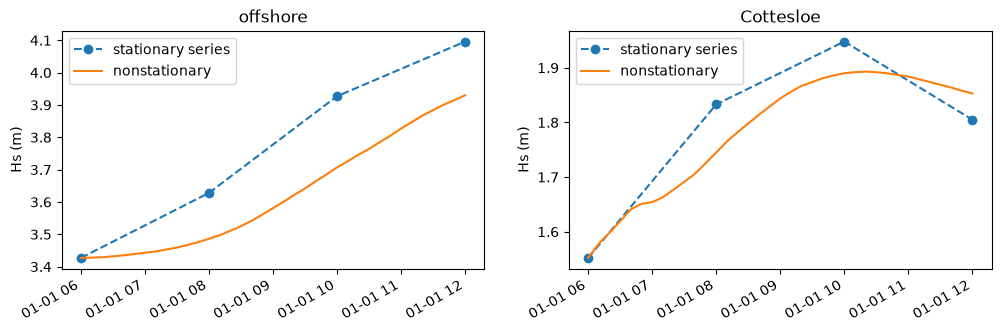

In [6]:
if len(tables) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)
    for ax, site in zip(axes, ["offshore", "Cottesloe"]):
        for (name, table), style in zip(tables.items(), ["o--", "-"]):
            data = table[table.site == site]
            ax.plot(data.time, data.hs, style, label=name)
        ax.set(title=site, ylabel="Hs (m)")
        ax.legend()
    fig.autofmt_xdate()

## Summary

- `MODE` decides whether the model has time; the `COMPUTE` commands decide how SWAN
  computes.
- The run period sets the computation times: one time, a series every interval, or
  nonstationary steps of one interval.
- A series of stationary computations suits small domains and allows long steps; a
  nonstationary computation follows the growth and travel of the waves.